# Decision Trees — Supervised Learning

Decision trees are one of those algorithms that actually make intuitive sense once you see them. The idea is pretty simple: you're building a flowchart of questions that eventually lead to a prediction. Unlike a lot of ML models that feel like black boxes, decision trees are transparent — you can follow the path from input to output and understand exactly why a prediction was made.

They work for both **classification** (predicting categories, like which species of flower this is) and **regression** (predicting a continuous value, like tomorrow's temperature). They also handle mixed data types well and don't require much preprocessing.

The main downside is that they tend to overfit if you let them grow too deep — they'll just memorize the training data. That's where pruning comes in, but we'll get to that later.

## Structure of a Decision Tree

Before getting into any math, here's how the tree is actually organized:

**Root Node** — The very first split. The root is chosen based on whichever feature gives the most information about the target. Think of it as the single most important question you can ask about the data.

**Decision Nodes** — All the internal nodes that come after the root. Each one represents another split, narrowing down the possibilities further. These are the follow-up questions.

**Leaf Nodes** — The endpoints. When a data point reaches a leaf, that's its final prediction. For classification, the leaf returns the majority class of the training samples that ended up there. For regression, it returns their average value.

**Branches** — The connections between nodes. Each branch is the outcome of a decision — for example, `petal_length > 2.45 → right branch` or `petal_length ≤ 2.45 → left branch`. Every split creates two (or more) branches.

## How the Tree Decides Where to Split

The tree doesn't randomly pick which feature to split on — it evaluates every feature and every possible threshold to find the split that reduces impurity the most. Here's how the process works:

**Choosing the Best Split**
At each node, the algorithm calculates the impurity (how mixed the classes are) of the current node, then checks what happens after each possible split. It picks the split that reduces impurity the most — this is called **information gain**.

**Splitting Recursively**
Once it finds the best split, it divides the data and runs the same process on each resulting subset. Each child node independently asks its own best question. This repeats until a stopping condition is met.

**Stopping Criteria**
The tree stops growing when:
- A node is completely pure (all samples belong to the same class)
- The node has too few samples to split
- The tree has hit its maximum allowed depth
- A split wouldn't improve impurity enough to be worth it

Without these stopping criteria, the tree keeps splitting until every leaf is pure — which means it has completely memorized the training data and will fall apart on anything new.

## Entropy

Entropy comes from information theory and measures how uncertain or "mixed up" the class distribution is at a given node.

- **When entropy = 0** — the node is completely pure: every sample belongs to the same class. No uncertainty at all.
- **When entropy is at maximum** — the classes are evenly distributed (50/50 for binary classification). Maximum uncertainty.

**Formula:**

$$H = -\sum p(x) \log_2 p(x)$$

Where $p(x)$ is the proportion of samples belonging to class $x$. You sum this over every class.

**When to use it:** Entropy tends to work well on smaller datasets. It considers all class probabilities and punishes impure splits a bit more aggressively than Gini does — which can be helpful when you care about getting rare classes right.

## Gini Impurity

Gini impurity measures the probability that a randomly chosen sample from a node would be *incorrectly* classified if it were labeled according to the class distribution of that node. In other words — how often would you get it wrong if you just guessed randomly based on what's in the node?

- **When Gini = 0** — the node is completely pure, everything is one class.
- **When Gini is at maximum** — for binary classification, that's **0.5**, when the two classes are split 50/50.

**Formula:**

$$G = 1 - \sum p(i)^2$$

Where $p(i)$ is the proportion of samples belonging to class $i$.

**When to use it:** Gini is computationally cheaper than entropy since it avoids log calculations. That makes it faster on larger datasets, and it's actually the default in scikit-learn's `DecisionTreeClassifier` for exactly that reason. It performs well in most situations without the extra overhead.

## Information Gain

Information gain tells us how much a split reduces uncertainty compared to the parent node. The higher the information gain, the more that split is worth making.

- **High IG** → the split cleanly separates the classes — this is a good split
- **Low IG** → the split barely changes the class distribution — not very useful

**Formula:**

$$IG = H(\text{parent}) - \sum \frac{|D_i|}{|D|} H(D_i)$$

Where $H$ is entropy, $D$ is the full dataset at the current node, and $D_i$ are the subsets produced by the split.

---

### Walking Through the Weather / Play Outside Example

Say we have 14 days of data and we want to predict whether someone played outside:

| Weather  | Yes | No | Total |
|----------|-----|----|-------|
| Sunny    | 2   | 3  | 5     |
| Overcast | 4   | 0  | 4     |
| Rainy    | 3   | 2  | 5     |
| **Total**| **9** | **5** | **14** |

**Step 1 — Parent entropy (before the split):**

$$H(\text{parent}) = -\frac{9}{14}\log_2\frac{9}{14} - \frac{5}{14}\log_2\frac{5}{14} \approx 0.940$$

**Step 2 — Entropy of each weather group:**

$$H(\text{Sunny}) = -\frac{2}{5}\log_2\frac{2}{5} - \frac{3}{5}\log_2\frac{3}{5} \approx 0.971$$

$$H(\text{Overcast}) = 0 \quad \text{(all Yes — completely pure!)}$$

$$H(\text{Rainy}) = -\frac{3}{5}\log_2\frac{3}{5} - \frac{2}{5}\log_2\frac{2}{5} \approx 0.971$$

**Step 3 — Weighted average of child entropies:**

$$\frac{5}{14}(0.971) + \frac{4}{14}(0) + \frac{5}{14}(0.971) \approx 0.694$$

**Step 4 — Information Gain:**

$$IG = 0.940 - 0.694 = 0.246$$

The algorithm computes this for every feature and picks the one with the highest IG to split on. In a real dataset, weather would be competing against features like humidity and wind speed.

## Pruning

Left unchecked, a decision tree will keep splitting until every leaf node is pure — which sounds great until you realize it's basically memorizing the training data. That's overfitting, and the model will fall apart on new data. Pruning is how we deal with this.

There are two main approaches:

---

### Pre-Pruning (Early Stopping)

Pre-pruning puts guardrails on the tree *while it's being built*, stopping it before it grows too complex:

- **Max depth** — caps how deep the tree can grow
- **Min samples to split** — a node won't split unless it has at least this many samples
- **Min samples per leaf** — every leaf must contain at least this many training examples
- **Max number of nodes** — a hard ceiling on the total number of nodes

**Pros:** Fast and memory-efficient; prevents overfitting during training  
**Cons:** You might stop too early and underfit — the tree never gets to learn useful patterns that only appear deeper down

---

### Post-Pruning (Trim After Training)

Post-pruning lets the tree grow fully first, then trims branches that aren't pulling their weight:

- **Reduced Error Pruning** — removes subtrees that don't improve (or hurt) validation accuracy
- **Cost Complexity Pruning** — adds a penalty for tree size, controlled by the `ccp_alpha` parameter; higher alpha = more pruning
- **Minimal Cost-Complexity Pruning** — evaluates a full sequence of pruned subtrees to find the best `ccp_alpha`

**Pros:** Usually leads to better generalization; gives you more precise control over the bias-variance tradeoff  
**Cons:** More computationally expensive since you grow the full tree first and then evaluate many subtrees

## Decision Tree Classifier — Iris Dataset

Time to actually build one. I'm using the Iris dataset here — 150 flower samples across 3 species, described by 4 features (sepal/petal length and width). Classic classification problem.

I'll train two versions:
1. **Post-pruning**: manually set `max_depth=2` to keep the tree shallow
2. **Pre-pruning via GridSearchCV**: let the search find the best hyperparameter combination across multiple options

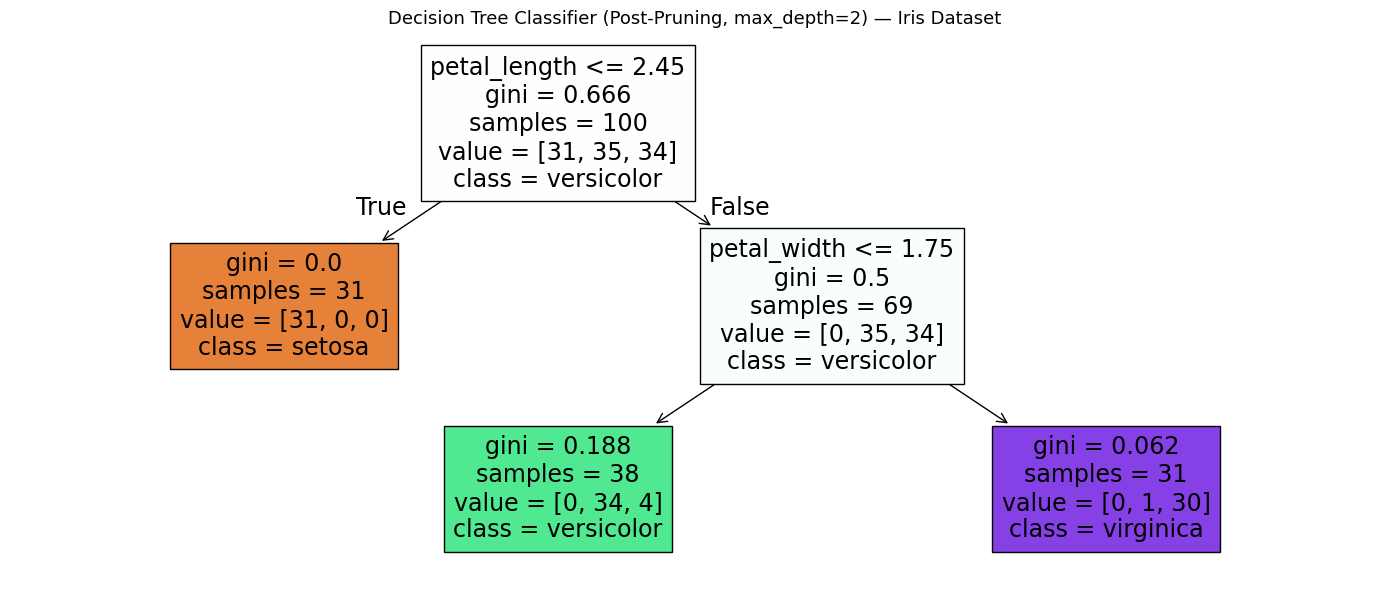

Accuracy (Post-Pruning): 0.98

Classification Report (Post-Pruning):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       0.94      1.00      0.97        15
   virginica       1.00      0.94      0.97        16

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50


Best Parameters found by GridSearchCV:
{'criterion': 'gini', 'max_depth': 2, 'max_features': 'sqrt', 'splitter': 'best'}

Classification Report (GridSearch Best Model):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       0.94      1.00      0.97        15
   virginica       1.00      0.94      0.97        16

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50


In [1]:
import seaborn as sns                                          # for loading the iris dataset
import numpy as np                                             # numerical operations
import matplotlib.pyplot as plt                               # plotting
from sklearn.model_selection import train_test_split, GridSearchCV  # splitting and hyperparameter search
from sklearn.tree import DecisionTreeClassifier, plot_tree    # the classifier and tree visualizer
from sklearn.metrics import accuracy_score, classification_report  # evaluation metrics

# Load the iris dataset from seaborn — returns a pandas DataFrame
iris = sns.load_dataset('iris')

# X = features (all columns except the target), y = target (species label)
X = iris.drop(columns='species')
y = iris['species']

# Hold out 33% of the data for testing, 67% used for training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

# --- Post-Pruning: limit tree depth directly ---
# max_depth=2 keeps the tree small and prevents it from memorizing training noise
clf = DecisionTreeClassifier(max_depth=2, random_state=42)
clf.fit(X_train, y_train)  # fit the classifier to the training data

# Visualize the trained tree — filled=True colors each node by its majority class
fig, ax = plt.subplots(figsize=(14, 6))
plot_tree(clf, feature_names=list(X.columns), class_names=list(clf.classes_), filled=True, ax=ax)
ax.set_title('Decision Tree Classifier (Post-Pruning, max_depth=2) — Iris Dataset', fontsize=13)
plt.tight_layout()
plt.show()

# Predict on the held-out test set
y_pred = clf.predict(X_test)  # generate class predictions
print('Accuracy (Post-Pruning):', accuracy_score(y_test, y_pred))
print('\nClassification Report (Post-Pruning):')
print(classification_report(y_test, y_pred))

# --- Pre-Pruning: find best hyperparameters using GridSearchCV ---
# This grid covers different split criteria, strategies, depths, and feature subsets
param_grid = {
    'criterion':    ['gini', 'entropy', 'log_loss'],  # impurity measure for split quality
    'splitter':     ['best', 'random'],               # how to choose the split at each node
    'max_depth':    [1, 2, 3, 4, 5],                  # range of tree depths to search over
    'max_features': ['sqrt', 'log2'],                  # number of features to consider per split
}

# GridSearchCV exhaustively tries every combination, evaluating each with 5-fold cross-validation
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),  # base estimator
    param_grid,                               # hyperparameter combinations to try
    cv=5,                                     # 5-fold cross-validation
    scoring='accuracy'                        # metric to optimize
)
grid_search.fit(X_train, y_train)  # run the full grid search on training data

# Print the winning hyperparameter combination
print('\nBest Parameters found by GridSearchCV:')
print(grid_search.best_params_)

# Predict using the best model (grid_search.predict uses best_estimator_ automatically)
y_pred_best = grid_search.predict(X_test)
print('\nClassification Report (GridSearch Best Model):')
print(classification_report(y_test, y_pred_best))

## Decision Tree Regression

Everything so far has been about classification, but decision trees handle regression just as well. The main difference is in what we're trying to minimize at each split.

**Variance in this context** refers to the spread of target values within a node. A node where the y-values are all over the place has high variance — it's not a clean, predictable group. A node where the values are tightly clustered has low variance, meaning predictions from that node will be more consistent.

**Variance Reduction** is the split criterion for regression trees — it plays the same role that information gain plays in classification. The idea:

1. Compute the variance of the parent node (how spread out the targets are)
2. For each candidate split, compute the weighted variance of the resulting child nodes
3. The variance reduction = parent variance − weighted child variance

$$\text{Variance Reduction} = \text{Var}(\text{parent}) - \sum \frac{|D_i|}{|D|} \text{Var}(D_i)$$

**The split with the highest variance reduction wins.** The process repeats recursively on each child node, just like in classification. At each leaf, the prediction is the **mean** of all target values in that leaf — so when a new sample lands there, that's the number it gets.

## Decision Tree Regressor — Implementation

Simple dataset here — just 10 points with a roughly linear relationship and a little noise added in. Small enough to visualize the whole tree, but enough to see how the regressor splits things up.

Mean Squared Error: 1.3800


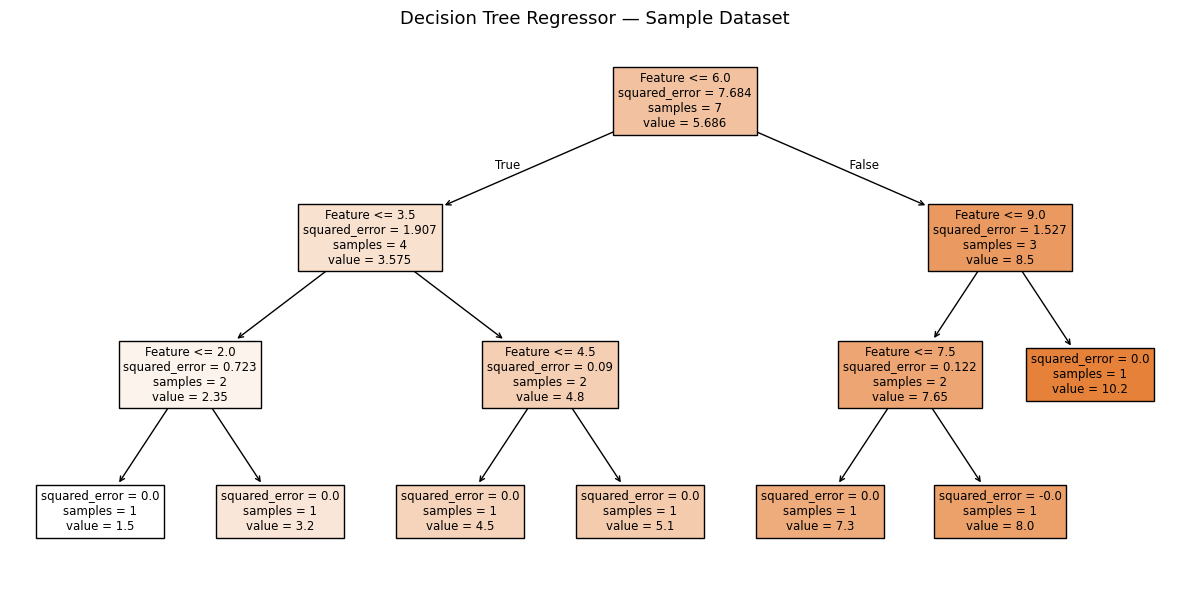

In [2]:
from sklearn.tree import DecisionTreeRegressor   # regression version of the decision tree
from sklearn.metrics import mean_squared_error   # error metric for regression

# Simple 10-point dataset — feature goes 1 to 10, targets are roughly linear with some noise
X_reg = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1)  # reshape to 2D column vector for sklearn
y_reg = np.array([1.5, 1.7, 3.2, 4.5, 5.1, 6.8, 7.3, 8.0, 9.1, 10.2])  # target values with slight noise

# Hold out 30% for testing — with only 10 points this is just 3 samples, but it's enough to evaluate
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

# Fit the regression tree — no depth limit, let it find the best splits
reg = DecisionTreeRegressor(random_state=42)
reg.fit(X_train_r, y_train_r)  # train on the training portion

# Generate predictions on the held-out test samples
y_pred_r = reg.predict(X_test_r)  # each prediction is the mean of its leaf node

# Mean squared error — average of (predicted - actual)^2, lower is better
mse = mean_squared_error(y_test_r, y_pred_r)
print(f'Mean Squared Error: {mse:.4f}')

# Visualize the tree structure — filled=True shades nodes by predicted value
fig, ax = plt.subplots(figsize=(12, 6))
plot_tree(reg, feature_names=['Feature'], filled=True, ax=ax)  # label the single feature axis
ax.set_title('Decision Tree Regressor — Sample Dataset', fontsize=13)
plt.tight_layout()
plt.show()